## Import Statements

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import re

## Parse data

In [2]:
file_pattern = "*.csv"
data_path = os.fspath("data/dec9_left/dec9")
data_files = glob.glob(file_pattern, root_dir=data_path)

# excluded_test_ids = {""}
excluded_test_ids = set(["left_3_5"])

print(f"Found {len(data_files)} data files")
test_id_set = set()
for file_name in data_files:
    file_prefix = file_name.split("_integrated")[0]
    test_id_set.add(file_prefix)
for test_id in test_id_set:
    if test_id in excluded_test_ids:
        print(f"Unique Test ID: {test_id} : Excluded from test sets")
    else:
        print(f"Unique Test ID: {test_id} : Included in test sets")


Found 27 data files
Unique Test ID: left_2_5 : Included in test sets
Unique Test ID: left_2_7 : Included in test sets
Unique Test ID: left_2_6 : Included in test sets
Unique Test ID: left_3_5 : Excluded from test sets
Unique Test ID: left_3_4 : Included in test sets
Unique Test ID: left_4_5 : Included in test sets
Unique Test ID: left_4_6 : Included in test sets
Unique Test ID: left_3_6 : Included in test sets
Unique Test ID: left_3_7 : Included in test sets


### Append data files to Pandas dataframe

In [3]:
df_list = []
for file_name in data_files:
    file_prefix = file_name.split("_integrated")[0]
    if file_prefix in excluded_test_ids:
        pass
    else:
        file = os.path.join(data_path, file_name)
        print(file_name)
        temp_df = pd.read_csv(file)
        temp_df.insert(0,"test_id",file_prefix)
        df_list.append(temp_df)
data_raw = pd.concat(df_list)
display(data_raw)
display(data_raw.dtypes)

left_2_5_integrated_measurement_data_20251209_16-26-41.csv
left_2_5_integrated_measurement_data_20251209_16-27-15.csv
left_2_5_integrated_measurement_data_20251209_16-27-48.csv
left_2_6_integrated_measurement_data_20251209_16-22-10.csv
left_2_6_integrated_measurement_data_20251209_16-22-45.csv
left_2_6_integrated_measurement_data_20251209_16-23-20.csv
left_2_7_integrated_measurement_data_20251209_16-18-05.csv
left_2_7_integrated_measurement_data_20251209_16-18-38.csv
left_2_7_integrated_measurement_data_20251209_16-19-11.csv
left_3_4_integrated_measurement_data_20251209_16-06-36.csv
left_3_4_integrated_measurement_data_20251209_16-07-21.csv
left_3_4_integrated_measurement_data_20251209_16-08-05.csv
left_3_6_integrated_measurement_data_20251209_15-27-52.csv
left_3_6_integrated_measurement_data_20251209_15-28-32.csv
left_3_6_integrated_measurement_data_20251209_15-29-13.csv
left_3_7_integrated_measurement_data_20251209_16-13-42.csv
left_3_7_integrated_measurement_data_20251209_16-14-18.c

,test_id,Time (s.ms),Force_gauge (N),Linear_position (mm),strain_0.0800m (µε),strain_1.2841m (µε),strain_0.0800m (µε).1,strain_0.0807m (µε),strain_0.0813m (µε),strain_0.0820m (µε),...,marker_11_z (m),marker_12_x (m),marker_12_y (m),marker_12_z (m),marker_13_x (m),marker_13_y (m),marker_13_z (m),marker_14_x (m),marker_14_y (m),marker_14_z (m)
0,left_2_5,47.229,0.00,0.006836,-0.100000,-6.299999,-0.100000,-6.699999,-15.500000,-7.500000,...,-32.200174,-88.610304,-170.451109,-1.918184,-98.200384,-197.500697,-2.606313,-116.535964,-160.838820,-2.730669
1,left_2_5,47.501,0.00,0.032227,3.799999,2.600000,3.799999,7.000000,-15.099998,-1.900000,...,-32.207912,-88.627797,-170.443551,-1.917860,-98.203040,-197.499782,-2.609745,-116.536307,-160.841514,-2.733839
2,left_2_5,47.773,0.00,0.057861,5.000000,-10.200001,5.000000,-2.000000,-6.700001,-6.900000,...,-32.190680,-88.652404,-170.433973,-1.900298,-98.222223,-197.496225,-2.594371,-116.556560,-160.828979,-2.714377
3,left_2_5,48.045,0.00,0.083740,1.900000,6.600000,1.900000,0.900000,-11.500000,-1.400000,...,-32.201513,-88.640665,-170.433263,-1.907913,-98.209400,-197.494161,-2.599848,-116.546385,-160.834921,-2.723099
4,left_2_5,48.317,0.00,0.109619,2.200001,-6.200001,2.200001,0.600000,-5.600000,-1.500000,...,-32.203707,-88.642968,-170.430009,-1.912186,-98.200896,-197.489116,-2.605723,-116.542989,-160.831992,-2.724709
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,left_4_6,27.614,0.09,2.808105,-1.200001,-6.799999,-1.200001,8.500000,6.500000,-6.299999,...,-41.645429,-165.430862,-235.174802,-1.339104,-183.992021,-256.955910,-2.104216,-188.190978,-216.235402,-2.230508
109,left_4_6,27.885,0.09,2.833984,-6.100000,-11.599998,-6.100000,7.000000,9.200001,5.300001,...,-41.638157,-165.431737,-235.175084,-1.344787,-183.990542,-256.957124,-2.102104,-188.192274,-216.233090,-2.231992
110,left_4_6,28.157,0.10,2.859619,-1.200001,-2.099998,-1.200001,4.000000,7.300001,6.600000,...,-41.634697,-165.430029,-235.179187,-1.346029,-183.997144,-256.960054,-2.100851,-188.192823,-216.237822,-2.233096
111,left_4_6,28.429,0.10,2.885498,3.100000,-6.200001,3.100000,4.600000,1.500000,1.600000,...,-41.600841,-165.434994,-235.163937,-1.327695,-183.994168,-256.950801,-2.088433,-188.195947,-216.225493,-2.222637


test_id                  object
Time (s.ms)             float64
Force_gauge (N)         float64
Linear_position (mm)    float64
strain_0.0800m (µε)     float64
                         ...   
marker_13_y (m)         float64
marker_13_z (m)         float64
marker_14_x (m)         float64
marker_14_y (m)         float64
marker_14_z (m)         float64
Length: 1907, dtype: object

### Remove extra gauges and sort by position along sensor

In [4]:
data = data_raw.loc[:, ~data_raw.columns.str.contains(r"\.\d+$")]

strain_cols = [col for col in data.columns if col.startswith("strain")]
other_cols = [col for col in data.columns if col not in strain_cols]

x_axis_raw = np.array([float(re.search(r"strain_(.*)m", x).group(1)) for x in strain_cols])
sorted_idx = np.argsort(x_axis_raw)
x_axis = np.sort(x_axis_raw)
sorted_strain_cols = [strain_cols[i] for i in sorted_idx]
data = data[other_cols + sorted_strain_cols]
display(data)

,test_id,Time (s.ms),Force_gauge (N),Linear_position (mm),marker_0_x (m),marker_0_y (m),marker_0_z (m),marker_1_x (m),marker_1_y (m),marker_1_z (m),...,strain_1.2806m (µε),strain_1.2812m (µε),strain_1.2818m (µε),strain_1.2825m (µε),strain_1.2831m (µε),strain_1.2838m (µε),strain_1.2841m (µε),strain_1.2845m (µε),strain_1.2851m (µε),strain_1.2858m (µε)
0,left_2_5,47.229,0.00,0.006836,-0.691230,-0.426719,-2.531907,30.782857,-0.584158,-2.677833,...,8.400009,9.900002,-1.4,2.699999,14.700001,7.000000,-6.299999,-2.700001,-8.500000,-6.299999
1,left_2_5,47.501,0.00,0.032227,-0.696594,-0.425367,-2.531350,30.780225,-0.585476,-2.683512,...,2.600006,8.900002,-8.4,3.199999,5.200001,-6.800003,2.600000,-14.900002,-9.500000,2.600000
2,left_2_5,47.773,0.00,0.057861,-0.720867,-0.425269,-2.508435,30.754546,-0.582019,-2.656512,...,9.400009,0.699997,-3.8,4.599998,8.200001,8.699999,-10.200001,-3.700001,-10.600002,-10.200001
3,left_2_5,48.045,0.00,0.083740,-0.712852,-0.421577,-2.516384,30.759304,-0.577615,-2.659860,...,1.200012,5.400002,-4.0,-2.799999,9.500000,-2.600002,6.600000,-8.500000,-9.300003,6.600000
4,left_2_5,48.317,0.00,0.109619,-0.701708,-0.420747,-2.528443,30.770937,-0.574343,-2.668834,...,6.900009,2.799995,-6.8,-1.500000,5.800001,-1.500000,-6.200001,-5.500000,-6.500000,-6.200001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,left_4_6,27.614,0.09,2.808105,-1.082193,1.671265,-2.058198,30.353499,1.312136,-2.119249,...,15.000000,-4.000000,3.7,7.100000,10.900000,3.500000,-6.799999,3.700001,-10.600002,-6.799999
109,left_4_6,27.885,0.09,2.833984,-1.081001,1.712844,-2.053607,30.348795,1.347836,-2.115084,...,3.100006,-7.299995,-1.5,10.500000,8.100000,-4.000000,-11.599998,1.800003,-13.900002,-11.599998
110,left_4_6,28.157,0.10,2.859619,-1.096140,1.760578,-2.039589,30.343691,1.390473,-2.098503,...,3.899994,-2.599998,-7.9,1.699999,7.400000,0.300003,-2.099998,0.200001,-9.400002,-2.099998
111,left_4_6,28.429,0.10,2.885498,-1.109992,1.806383,-2.026561,30.335014,1.439222,-2.086569,...,17.000000,-3.099998,-10.1,-1.300001,9.799999,-1.000000,-6.200001,9.900002,-6.000000,-6.200001


## Data Processing

### Visualize strain ranges

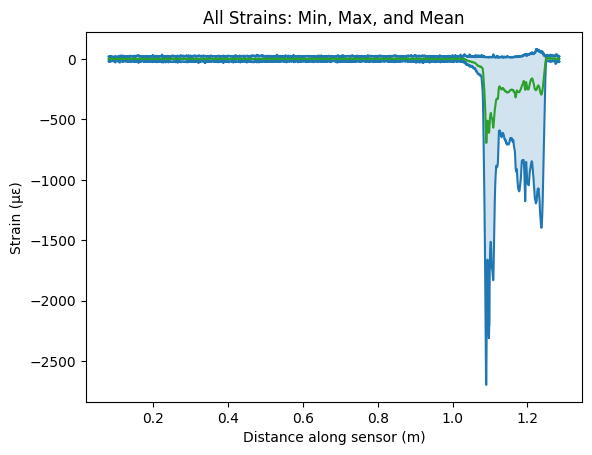

In [5]:
upper_bound = data[sorted_strain_cols].max()
lower_bound = data[sorted_strain_cols].min()
mean_line = data[sorted_strain_cols].mean()

fig, ax = plt.subplots()
ax.plot(x_axis,upper_bound,color='tab:blue')
ax.plot(x_axis,lower_bound,color='tab:blue')
ax.plot(x_axis,mean_line,color='tab:green')
ax.fill_between(x_axis,upper_bound,lower_bound,alpha=0.2)
ax.set_title("All Strains: Min, Max, and Mean")
ax.set_ylabel("Strain (με)")
ax.set_xlabel("Distance along sensor (m)")
plt.show()

### Cutoff excess early data

,strain_1.0199m (µε),strain_1.0206m (µε),strain_1.0212m (µε),strain_1.0218m (µε),strain_1.0225m (µε),strain_1.0231m (µε),strain_1.0238m (µε),strain_1.0244m (µε),strain_1.0251m (µε),strain_1.0258m (µε),...,strain_1.2806m (µε),strain_1.2812m (µε),strain_1.2818m (µε),strain_1.2825m (µε),strain_1.2831m (µε),strain_1.2838m (µε),strain_1.2841m (µε),strain_1.2845m (µε),strain_1.2851m (µε),strain_1.2858m (µε)
0,-4.099998,0.600002,18.300003,6.500000,-9.899998,-6.200001,-1.099998,-0.900002,-5.000000,-7.200001,...,8.400009,9.900002,-1.4,2.699999,14.700001,7.000000,-6.299999,-2.700001,-8.500000,-6.299999
1,-2.599998,-3.399998,15.400002,8.399998,-3.199997,-8.099998,-8.400002,-1.100002,-5.599998,-4.500000,...,2.600006,8.900002,-8.4,3.199999,5.200001,-6.800003,2.600000,-14.900002,-9.500000,2.600000
2,-9.200001,-7.700001,10.200005,11.399998,-1.199997,1.299999,-9.500000,-0.900002,0.600002,1.000000,...,9.400009,0.699997,-3.8,4.599998,8.200001,8.699999,-10.200001,-3.700001,-10.600002,-10.200001
3,-5.299999,-11.399998,5.800003,9.000000,-0.899998,-5.299999,1.599998,1.299999,-4.899998,-2.600002,...,1.200012,5.400002,-4.0,-2.799999,9.500000,-2.600002,6.600000,-8.500000,-9.300003,6.600000
4,-5.200001,-4.799999,10.500004,5.299999,-7.000000,-12.599998,-7.299999,-1.500000,1.700001,4.700001,...,6.900009,2.799995,-6.8,-1.500000,5.800001,-1.500000,-6.200001,-5.500000,-6.500000,-6.200001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,-1.600002,-7.400002,10.299999,-1.200001,8.599998,-7.000000,-11.900002,2.000000,2.799999,0.600002,...,15.000000,-4.000000,3.7,7.100000,10.900000,3.500000,-6.799999,3.700001,-10.600002,-6.799999
109,0.699997,-5.000000,-2.099998,5.399998,9.200001,-9.099998,-8.599998,-7.800003,-1.100002,0.200001,...,3.100006,-7.299995,-1.5,10.500000,8.100000,-4.000000,-11.599998,1.800003,-13.900002,-11.599998
110,-12.900002,-17.200001,3.799999,8.399998,7.799999,-13.700001,-6.700001,-2.500000,0.299999,-6.599998,...,3.899994,-2.599998,-7.9,1.699999,7.400000,0.300003,-2.099998,0.200001,-9.400002,-2.099998
111,1.599998,-4.900002,4.200001,0.399998,8.700001,-7.599998,-6.900002,-1.300003,5.699997,-1.500000,...,17.000000,-3.099998,-10.1,-1.300001,9.799999,-1.000000,-6.200001,9.900002,-6.000000,-6.200001


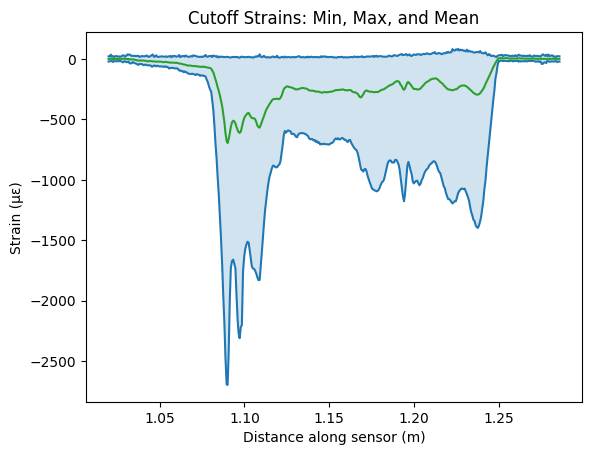

In [6]:
start_location = 1.02
cutoff_idx = (np.abs(x_axis - start_location)).argmin()
cutoff_strain = data[sorted_strain_cols].iloc[:,cutoff_idx:]
cutoff_x_axis = x_axis[cutoff_idx:]

upper_bound = cutoff_strain.max()
lower_bound = cutoff_strain.min()
mean_line = cutoff_strain.mean()

fig, ax = plt.subplots()
ax.plot(cutoff_x_axis,upper_bound,color='tab:blue')
ax.plot(cutoff_x_axis,lower_bound,color='tab:blue')
ax.plot(cutoff_x_axis,mean_line,color='tab:green')
ax.fill_between(cutoff_x_axis,upper_bound,lower_bound,alpha=0.2)
ax.set_title("Cutoff Strains: Min, Max, and Mean")
ax.set_ylabel("Strain (με)")
ax.set_xlabel("Distance along sensor (m)")
display(cutoff_strain)
plt.show()

### Remove NAN values

In [7]:
display(cutoff_strain.isna().sum().sum())
cutoff_strain.interpolate(inplace=True, axis=0)
cutoff_strain.interpolate(inplace=True, axis=1)
display(cutoff_strain.isna().sum().sum())

np.int64(0)

np.int64(0)

Custom cv

In [8]:
cv_split_array = np.zeros(len(data.test_id))
test_id_array = data.test_id.to_numpy()
i = 0
test_id_names = []
for test_id in test_id_set:
    if test_id in excluded_test_ids:
        split_idx = -1
    else:
        split_idx = i
        test_id_names.append(test_id)
        i += 1
    cv_split_array = np.where(test_id_array == test_id, split_idx, cv_split_array)
print(f"Generated {i} test sets")
print(f"{data["test_id"].value_counts()}")
for test_id in test_id_names:
    test_id_rows = data.loc[data['test_id'] == test_id]


Generated 8 test sets
test_id
left_3_4    375
left_4_5    371
left_4_6    341
left_3_6    328
left_3_7    281
left_2_6    267
left_2_5    250
left_2_7    249
Name: count, dtype: int64


## Visualize Vicon Data

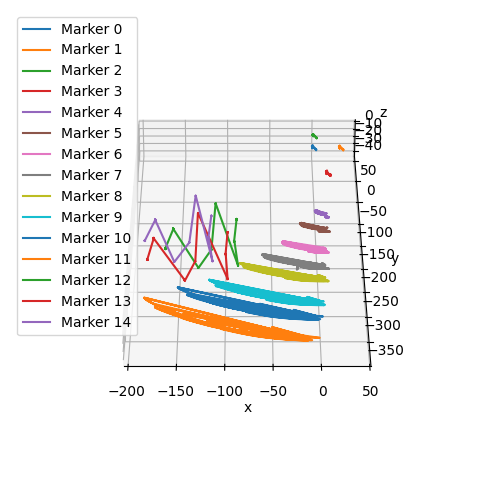

In [9]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
for i in range(15):
    x = data[f"marker_{i}_x (m)"]
    y = data[f"marker_{i}_y (m)"]
    z = data[f"marker_{i}_z (m)"]
    ax.plot(x,y,z, label=f"Marker {i}")
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init( azim=-90)
ax.legend(loc="upper left")
plt.show()

## Geometric Parameters

In [10]:
# Dimensions in mm
manipulator_width = 15
sensor_length = 26.75

## 2D Contact Representation

In [11]:
sensor_base_x = data["marker_14_x (m)"]
sensor_base_y = data["marker_14_y (m)"]
sensor_base = np.array([sensor_base_x, sensor_base_y])
sensor_end_x = data["marker_12_x (m)"]
sensor_end_y = data["marker_12_y (m)"]
sensor_end = np.array([sensor_end_x, sensor_end_y])
sensor_delta = sensor_end - sensor_base
sensor_tip = sensor_end + sensor_length * (sensor_delta / 14.16)
data["sensor_tip_x"] = sensor_tip[0,:]
data["sensor_tip_y"] = sensor_tip[1,:]

contact_pos_x = np.empty((len(data)))
contact_pos_y = np.empty((len(data)))
contact_t = np.empty((len(data)))
contact_n = np.empty((len(data)),dtype=int)
contact_dist = np.full((len(data)),np.inf)

for i in range(4,12):
    marker_pos = np.array([data[f"marker_{i}_x (m)"], data[f"marker_{i}_y (m)"]])
    if i == 4:
        prev_marker_pos = marker_pos + np.array([0,1])[:, np.newaxis]
    else:
        prev_marker_pos = np.array([data[f"marker_{i-1}_x (m)"], data[f"marker_{i-1}_y (m)"]])
    delta = marker_pos - prev_marker_pos
    delta_u = delta / np.linalg.norm(delta,axis=0)
    normal = np.array([-np.array(delta_u[1,:]), delta_u[0,:]])
    left_marker_pos = marker_pos - manipulator_width*normal/2
    right_marker_pos = marker_pos + manipulator_width*normal/2
    data[f"left_marker_{i}_x"] = left_marker_pos[0]
    data[f"left_marker_{i}_y"] = left_marker_pos[1]
    data[f"right_marker_{i}_x"] = right_marker_pos[0]
    data[f"right_marker_{i}_y"] = right_marker_pos[1]

    A = np.array([sensor_delta, -delta_u]).T

    b_left = (left_marker_pos - sensor_tip).T
    y_left = np.linalg.solve(A, b_left[:,:,np.newaxis])
    b_right = (right_marker_pos - sensor_tip).T
    y_right = np.linalg.solve(A, b_right[:,:,np.newaxis])

    contact_left = left_marker_pos + y_left[:,1].T*delta_u
    contact_right = right_marker_pos + y_right[:,1].T*delta_u
    contact_dist_left = np.linalg.norm(sensor_tip - contact_left, axis=0)
    contact_dist_right = np.linalg.norm(sensor_tip - contact_right, axis=0)

    for j, _ in enumerate(contact_dist):
        if contact_dist_left[j] < contact_dist[j]:
            contact_dist[j] = contact_dist_left[j]
            contact_pos_x[j] = contact_left[0,j]
            contact_pos_y[j] = contact_left[1,j]
            contact_t[j] = i - 4 + y_left[j,1,0]/np.linalg.norm(delta,axis=0)[j]
            contact_n[j] = int(i - 4)


0     -116.535964
1     -116.536307
2     -116.556560
3     -116.546385
4     -116.542989
          ...    
108   -188.190978
109   -188.192274
110   -188.192823
111   -188.195947
112   -188.210610
Name: marker_14_x (m), Length: 2462, dtype: float64


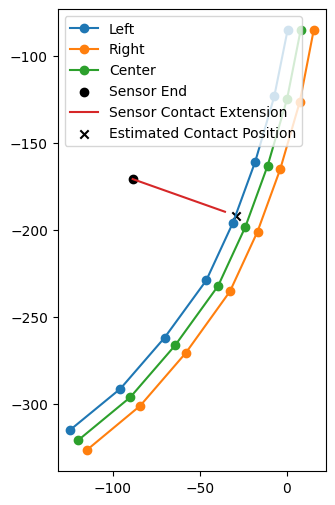

In [12]:
row = np.argmax(data["Force_gauge (N)"])
left_x_data = [data.iloc[row][f"left_marker_{i}_x"] for i in range(4,12)]
left_y_data = [data.iloc[row][f"left_marker_{i}_y"] for i in range(4,12)]
right_x_data = [data.iloc[row][f"right_marker_{i}_x"] for i in range(4,12)]
right_y_data = [data.iloc[row][f"right_marker_{i}_y"] for i in range(4,12)]
center_x_data = [data.iloc[row][f"marker_{i}_x (m)"] for i in range(4,12)]
center_y_data = [data.iloc[row][f"marker_{i}_y (m)"] for i in range(4,12)]

sensor_end_x = data.iloc[row]["marker_12_x (m)"]
sensor_end_y = data.iloc[row]["marker_12_y (m)"]
sensor_tip_x = data.iloc[row]["sensor_tip_x"]
sensor_tip_y = data.iloc[row]["sensor_tip_y"]
fig = plt.figure(figsize=(16,6))
ax = fig.add_subplot()

ax.plot(left_x_data, left_y_data, "o-")
# ax.scatter(left_x_data, left_y_data)

ax.plot(right_x_data, right_y_data, "o-")
# ax.scatter(right_x_data, right_y_data)

ax.plot(center_x_data, center_y_data, "o-")
# ax.scatter(center_x_data, center_y_data)
# ax.scatter(sensor_base_x[row], sensor_base_y[row], color="black")
print(sensor_base_x)
ax.scatter(sensor_end_x, sensor_end_y, color="black", marker='o')
ax.plot([sensor_end_x, sensor_tip_x], [sensor_end_y, sensor_tip_y])
ax.scatter(contact_pos_x[row], contact_pos_y[row], marker='x', color='black')

ax.set_aspect('equal')
ax.legend(["Left","Right","Center", "Sensor End", "Sensor Contact Extension", "Estimated Contact Position"])
plt.show()
# print(contact_t[row])


In [13]:
data["contact_dist"] = contact_dist
data["contact_t"] = contact_t
data["contact_n"] = contact_n
display(data[["Time (s.ms)","Force_gauge (N)", "sensor_tip_x","sensor_tip_y","contact_dist","contact_t","contact_n"]])
test = data[["test_id","Time (s.ms)","Force_gauge (N)", "sensor_tip_x","sensor_tip_y","contact_dist","contact_t","contact_n"]]
test.to_csv("test.csv")

,Time (s.ms),Force_gauge (N),sensor_tip_x,sensor_tip_y,contact_dist,contact_t,contact_n
0,47.229,0.00,-35.855263,-188.609917,37.910052,2.730638,2
1,47.501,0.00,-35.905154,-188.582992,37.949217,2.730140,2
2,47.773,0.00,-35.937985,-188.579002,37.943834,2.730489,2
3,48.045,0.00,-35.923291,-188.565724,37.924910,2.729649,2
4,48.317,0.00,-35.936359,-188.561857,37.926132,2.729863,2
...,...,...,...,...,...,...,...
108,27.614,0.09,-122.434173,-270.953681,8.555133,5.891249,6
109,27.885,0.09,-122.434254,-270.958864,8.577247,5.895883,6
110,28.157,0.10,-122.428281,-270.961780,8.580459,5.900246,6
111,28.429,0.10,-122.436724,-270.941012,8.612558,5.904579,6


In [14]:
xdata = cutoff_strain
ydata = np.zeros((len(cutoff_strain),max(data["contact_n"]) + 1))
ydata[np.arange(len(cutoff_strain)), data["contact_n"]] = data["Force_gauge (N)"]
display(pd.DataFrame(ydata))
# Seperate validation indexes

,0,1,2,3,4,5,6,7
0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
...,...,...,...,...,...,...,...,...
2457,0.0,0.0,0.0,0.0,0.0,0.0,0.09,0.0
2458,0.0,0.0,0.0,0.0,0.0,0.0,0.09,0.0
2459,0.0,0.0,0.0,0.0,0.0,0.0,0.10,0.0
2460,0.0,0.0,0.0,0.0,0.0,0.0,0.10,0.0



Training with left_2_5 holdout

Training on cuda
Training samples: 1970, Validation samples: 492
Input length: 411, Output size: 8

Epoch 10/100 - Train Loss: 0.047611, Val Loss: 0.414349
Epoch 20/100 - Train Loss: 0.034591, Val Loss: 0.327843
Epoch 30/100 - Train Loss: 0.030761, Val Loss: 0.365864
Epoch 40/100 - Train Loss: 0.027072, Val Loss: 0.345087

Early stopping at epoch 44

Best validation loss: 0.290149

Training with left_2_7 holdout

Training on cuda
Training samples: 1970, Validation samples: 492
Input length: 411, Output size: 8

Epoch 10/100 - Train Loss: 0.064582, Val Loss: 0.628658
Epoch 20/100 - Train Loss: 0.028565, Val Loss: 0.748601
Epoch 30/100 - Train Loss: 0.025311, Val Loss: 0.730446

Early stopping at epoch 32

Best validation loss: 0.510176

Training with left_2_6 holdout

Training on cuda
Training samples: 1970, Validation samples: 492
Input length: 411, Output size: 8

Epoch 10/100 - Train Loss: 0.032357, Val Loss: 2.269300
Epoch 20/100 - Train Loss: 0.0205

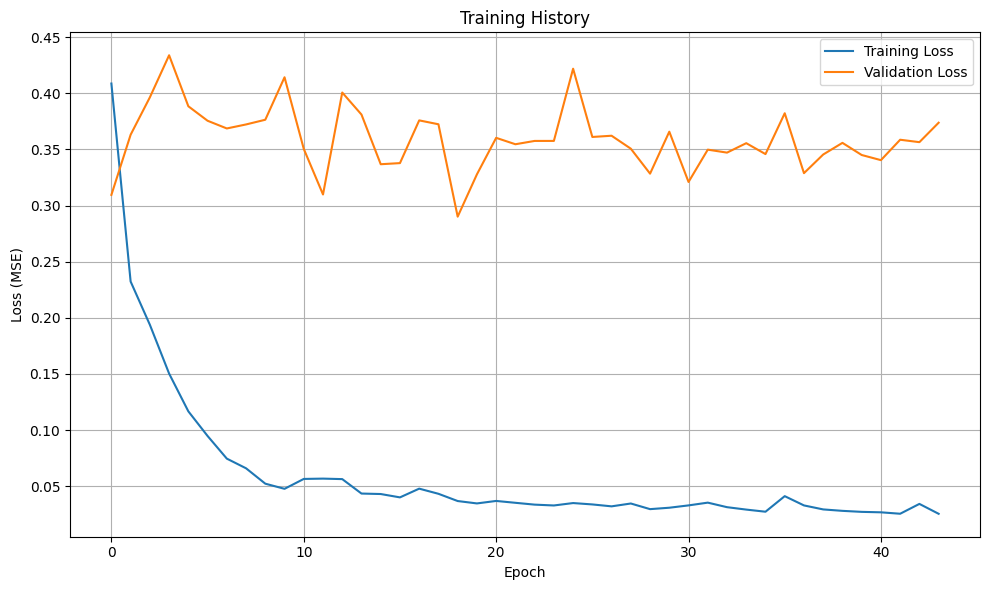

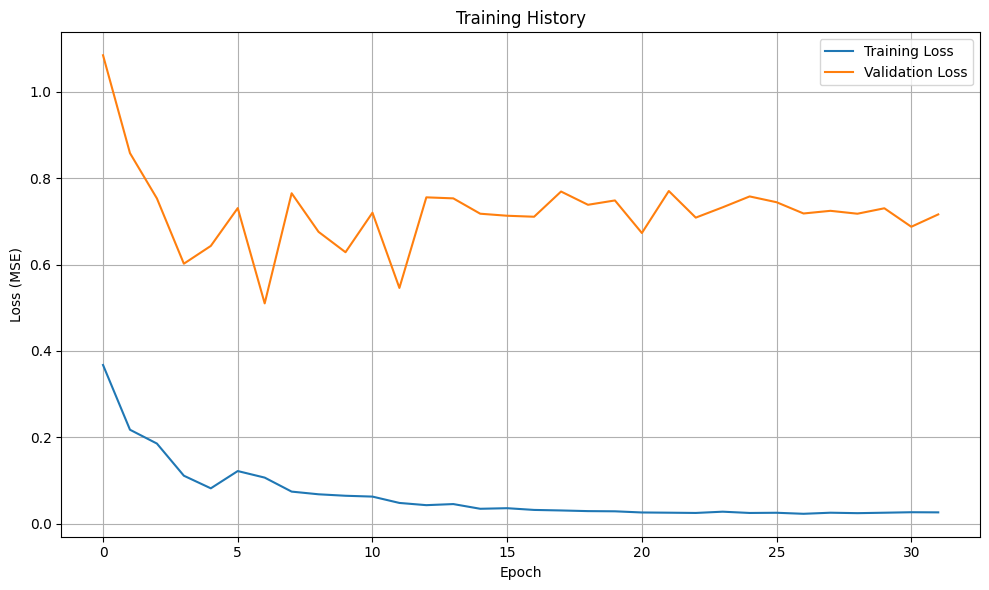

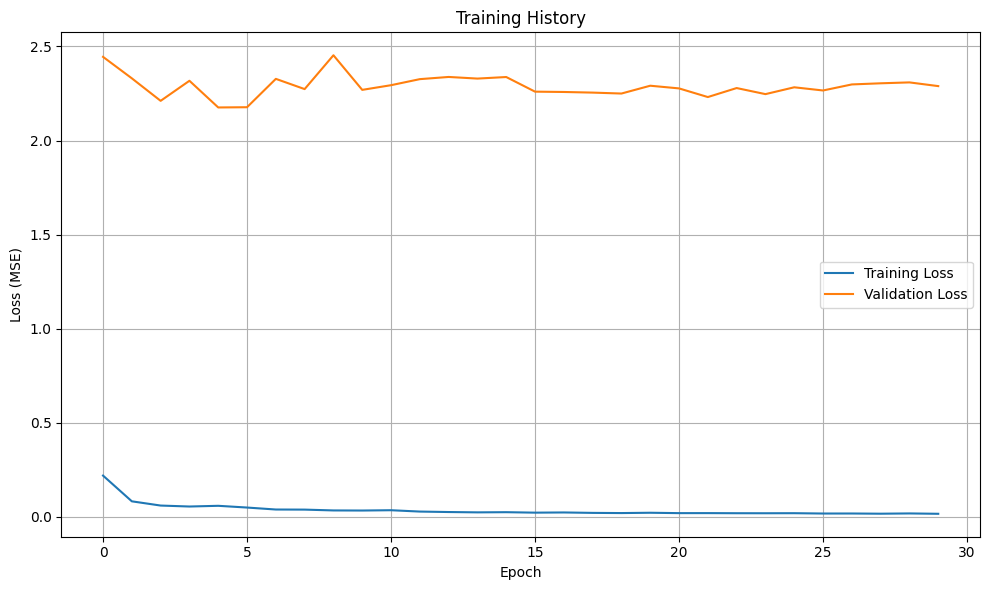

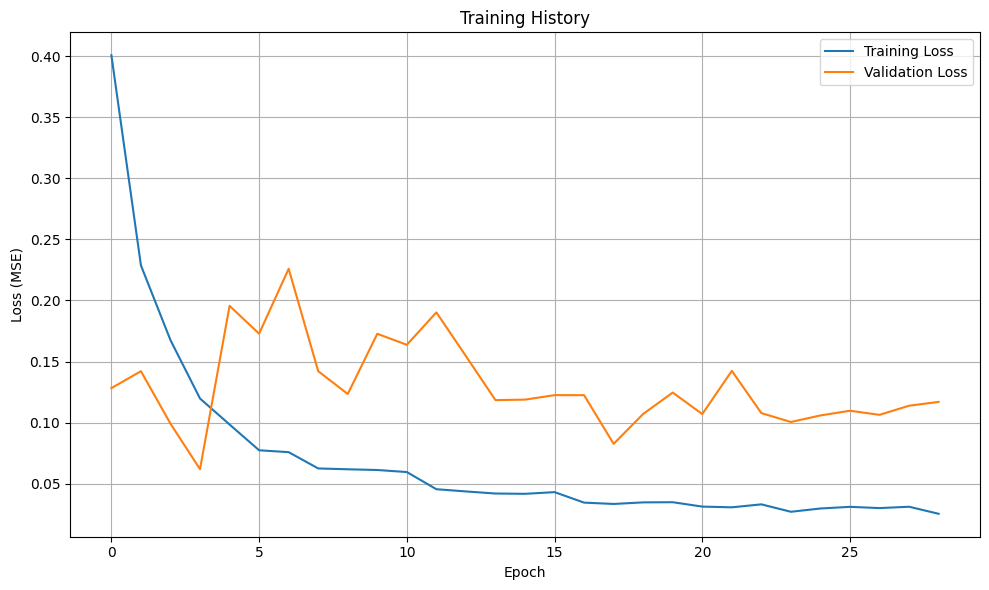

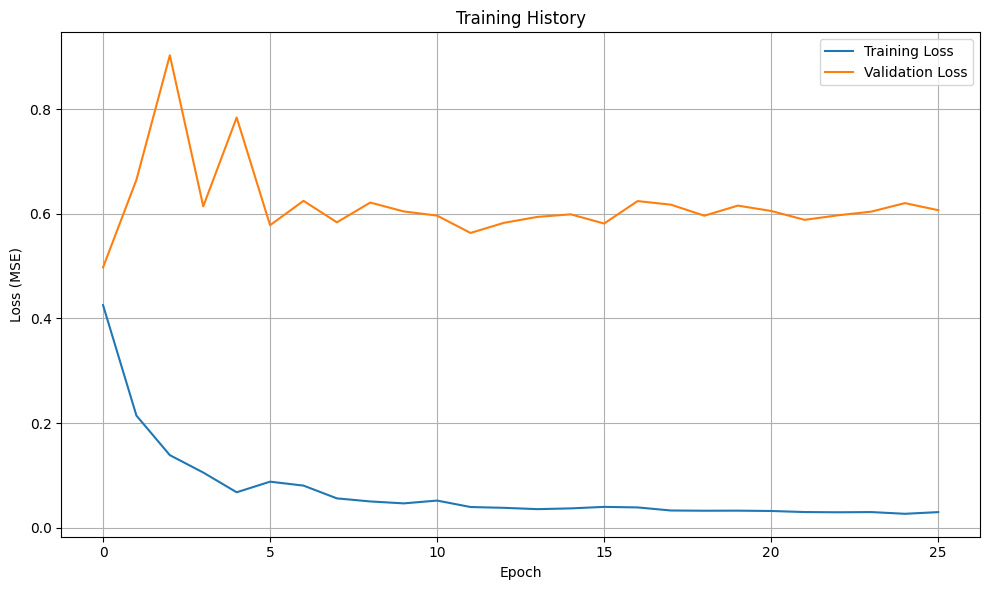

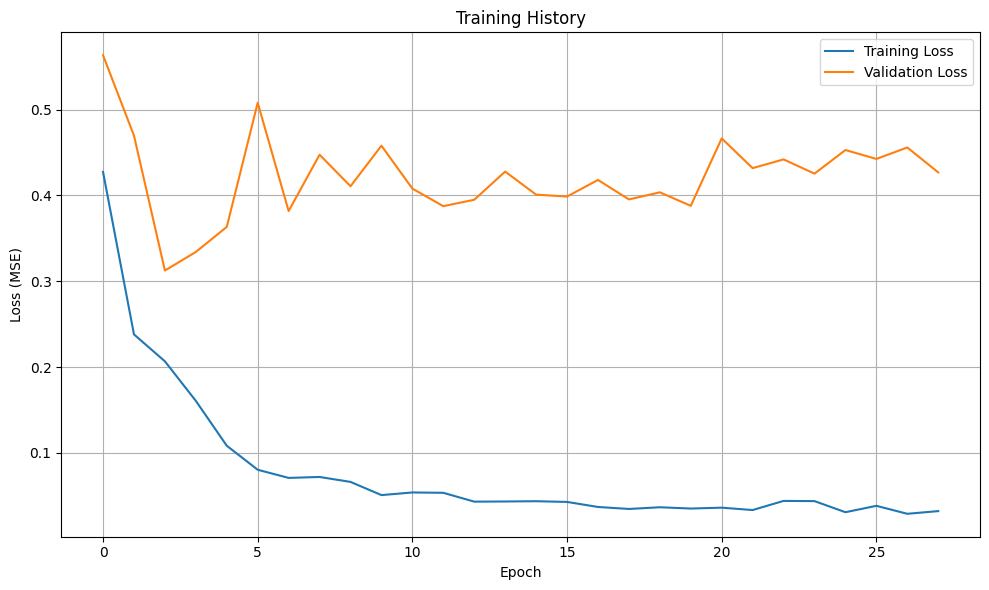

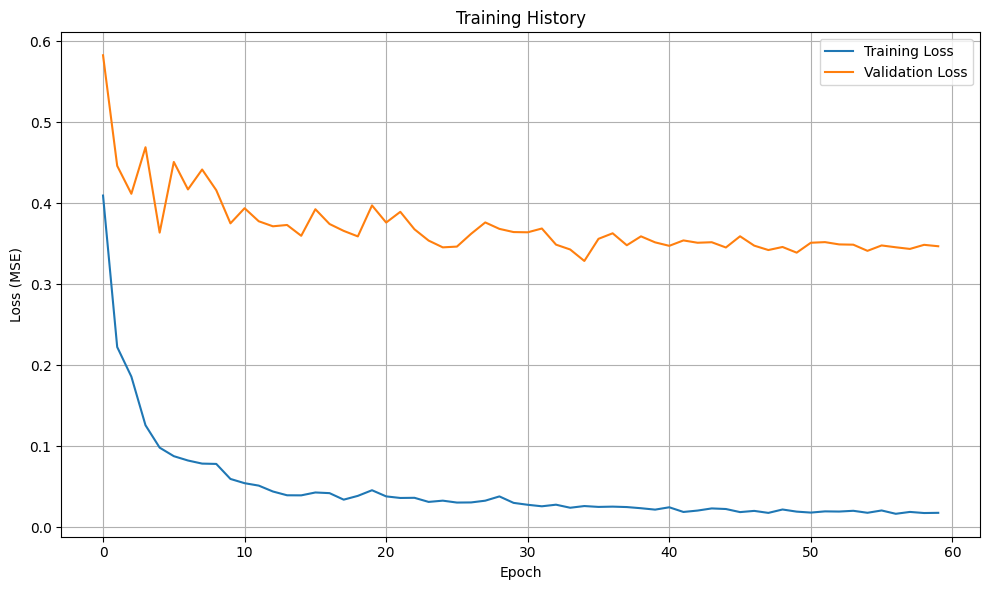

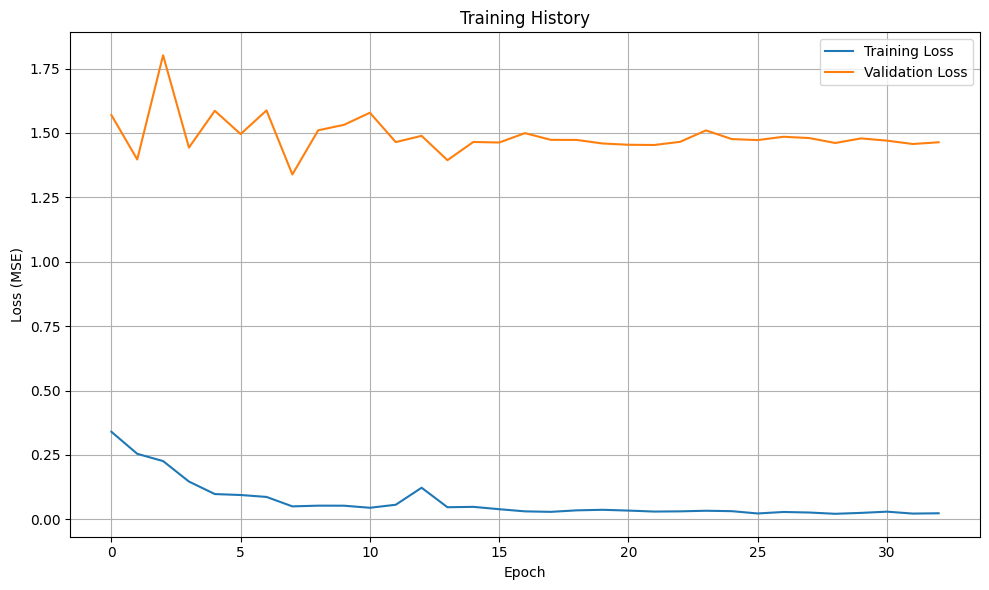

In [15]:
from strainCNN import train_model, predict, plot_training_history
import torch
model_dict = dict()
history_dict = dict()
dataset_dict = dict()
fig_dict = dict()
for i, id in enumerate(test_id_names):

    print()
    print(f"Training with {id} holdout")
    print()

    train_idxs = np.where(cv_split_array != i)[0]
    test_idxs = np.where(cv_split_array == i)[0]

    model, history, dataset = train_model(
        xdata, 
        ydata,
        train_idxs,
        test_idxs,
        epochs=100,           # Maximum number of epochs
        batch_size=32,        # Batch size
        learning_rate=0.0005,  # Learning rate
        val_split=0.2,        # 20% validation split
        patience=25           # Early stopping patience
    )

    model_dict[id] = model
    history_dict[id] = history
    dataset_dict[id] = dataset
    fig_dict[id] = plot_training_history(history)

In [16]:
for id in test_id_names:
    model = model_dict[id]
    dataset = dataset_dict[id]
    # Full predictions
    print()
    print(f"Holdout test set: {id}")
    print()
    all_predictions = predict(model, dataset, xdata)

    # Find predicted contact points
    predicted_contacts = np.argmax(all_predictions, axis=1)
    actual_contacts = np.argmax(ydata, axis=1)

    # Contact point accuracy
    contact_accuracy = (predicted_contacts == actual_contacts).mean()
    contact_mae = np.abs(predicted_contacts - actual_contacts).mean()
    print(f"Contact Point Classification Accuracy: {contact_accuracy*100:.2f}%")
    print(f"Contact Point Classification MAE: {contact_mae:.2f} Segments")
    # plt.hist(predicted_contacts,bins=7,color='red',alpha=0.5,label="Predicted")
    # plt.hist(actual_contacts,bins=7,color='blue',alpha=0.5,label="Actual")
    # plt.xlabel("Contact Segment")
    # plt.ylabel("Count")
    # plt.legend()
    # plt.show()

    force_errors = []
    for i in range(len(all_predictions)):
        actual_force = ydata[i, actual_contacts[i]]
        pred_force = all_predictions[i, actual_contacts[i]]
        # if actual_force != 0:  # Only evaluate non-zero forces
        force_errors.append(abs(actual_force - pred_force))

    if force_errors:
        mean_force_error = np.mean(force_errors)
        median_force_error = np.median(force_errors)
        print(f"Mean Absolute Force Error (at all positions): {mean_force_error:.5f} N")
        print(f"Median Absolute Force Error (at all positions): {median_force_error:.5f} N")

    correct_predictions = predicted_contacts == actual_contacts
    classified_force_errors = []
    for i in np.where(correct_predictions)[0]:
        actual_force = ydata[i, actual_contacts[i]]
        pred_force = all_predictions[i, actual_contacts[i]]
        if actual_force != 0:
            classified_force_errors.append(abs(actual_force - pred_force))

    if classified_force_errors:
        mean_force_error = np.mean(classified_force_errors)
        median_force_error = np.median(classified_force_errors)
        print(f"Mean Absolute Force Error (at correctly located positions): {mean_force_error:.5f} N")
        print(f"Median Absolute Force Error (at correctly located positions): {median_force_error:.5f} N")



Holdout test set: left_2_5

Contact Point Classification Accuracy: 67.95%
Contact Point Classification MAE: 1.40 Segments
Mean Absolute Force Error (at all positions): 0.00830 N
Median Absolute Force Error (at all positions): 0.00618 N
Mean Absolute Force Error (at correctly located positions): 0.00700 N
Median Absolute Force Error (at correctly located positions): 0.00452 N

Holdout test set: left_2_7

Contact Point Classification Accuracy: 33.27%
Contact Point Classification MAE: 1.84 Segments
Mean Absolute Force Error (at all positions): 0.01052 N
Median Absolute Force Error (at all positions): 0.00734 N
Mean Absolute Force Error (at correctly located positions): 0.00582 N
Median Absolute Force Error (at correctly located positions): 0.00539 N

Holdout test set: left_2_6

Contact Point Classification Accuracy: 60.36%
Contact Point Classification MAE: 1.11 Segments
Mean Absolute Force Error (at all positions): 0.01051 N
Median Absolute Force Error (at all positions): 0.00834 N
Mean 